# RQ3 — Structural weaknesses of Mutang

**Mutang** (`MutationEnumerationInTangentSpace`) encodes a peptide with HydrAMP, takes the **decoder Jacobian**, runs an **SVD**, and turns the top singular directions into candidate point mutations. Two thresholds and the Jacobian-computation choice drive everything:

- `direction_significance_threshold` — how many singular directions count as "significant".
- `token_threshold` — which amino acids per position become candidate substitutions.
- `jacobian_mode` ∈ {`strict` (exact autograd), `approx` (finite difference, step `jacobian_eps`)}.

This notebook empirically probes three weaknesses, using helpers in [`scripts/mutang/stability.py`](../../../scripts/mutang/stability.py):

- **(a) Combinatorial explosion** — `mutate_peptide` takes the **Cartesian product** of per-position candidates, so the joint count grows multiplicatively.
- **(b) Threshold instability across peptides** — a threshold that is reasonable for one peptide produces very different output for another.
- **(c) Jacobian-approximation sensitivity** — a poorly chosen `eps` distorts the SVD (singular values, singular subspace) and therefore the enumerated mutations.

Scope is **enumeration-level** (no APEX scoring). Everything runs on CPU.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# --- locate repo root so `scripts.mutang.stability` and `pep_compass` import ---
_here = Path.cwd()
ROOT = next(
    (p for p in [_here, *_here.parents] if (p / "analysis").is_dir() and (p / "src").is_dir()),
    _here,
)
for sub in ("analysis", "src"):
    sp = str(ROOT / sub)
    if sp not in sys.path:
        sys.path.insert(0, sp)

from scripts.mutang import stability as st  # noqa: E402

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

# Run-size toggles ----------------------------------------------------------
RUN_B_1000 = True    # (b) cross-peptide CV on 1000 peptides (cheap, ~70s)
RUN_C_1000 = False   # (c) eps sweep on 1000 peptides (needs exact Jacobian; slow)
SAMPLE_C = 100       # peptides used for the (c) eps sweep (each needs 1 exact Jacobian)

print("repo root:", ROOT)
model = st.load_model(device="cpu")  # HydrAMP weights bundled under src/
print("HydrAMP loaded | latent", model.latent_dim, "| ambient", model.ambient_dim)

# shared SVD cache so repeated sweeps over the same peptide reuse one SVD
cache = {}

repo root: C:\Users\Karol\Desktop\PepCompass\pep-compass
HydrAMP loaded | latent 64 | ambient 525


## Peptide selection & justification

**6 benchmark peptides** — the project's actual SAASBO optimization targets (`scripts/run_optimization.py`). Mutang's weaknesses matter most *exactly* on the peptides we optimize. They span lengths 10–19 with varied charge/composition, giving per-peptide detail and qualitative diversity. Keeping this set small keeps the expensive **exact-Jacobian** sweep in (c) tractable.

**100 sampled** (seeded, from `veltri_positive.csv`, length ≤ 25, standard residues only) — a statistically meaningful distribution for the cross-peptide variance claim in (b) and the eps-sensitivity spread in (c), beyond anecdote.

**1000 sampled** — stress test confirming the (b) instability trend is not a small-sample artifact (uses only the cheap approx path). Note: the length/alphabet filter trims the request, so fewer than 1000 valid peptides may remain (the realized count is printed below)."


In [2]:
VELTRI = ROOT / "results" / "data" / "veltri_positive.csv"

benchmarks = st.BENCHMARK_PEPTIDES
sample_100 = st.sample_peptides(VELTRI, 100, seed=0)
sample_1000 = st.sample_peptides(VELTRI, 1000, seed=0)

print(f"benchmarks: {len(benchmarks)} | sample_100: {len(sample_100)} | sample_1000: {len(sample_1000)}")

bench_df = pd.DataFrame(
    [{"name": n, "sequence": s, "length": len(s)} for n, s in benchmarks.items()]
).sort_values("length")
display(bench_df)
print("benchmark length range:", bench_df.length.min(), "-", bench_df.length.max())

benchmarks: 6 | sample_100: 100 | sample_1000: 892


,name,sequence,length
4,mammuthusin-3,KTLKIIRLLF,10
0,middle-1,FLYKWWIRIGRLKL,14
1,jurand-4,KYCRRFRWLTFRWL,14
2,jurand-2,KFRNRHRWKFKLIFRN,16
3,jurand-7,KKYWLIRKWIRLWFLT,16
5,hydrodamin-2,RMARNLVRYVQGLKKKKVI,19


benchmark length range: 10 - 19


## (a) Cartesian-product combinatorial explosion

Mutang's `get_mutations_from_s_u` yields, per significant direction, a set of candidate residues at one position. `mutate_peptide`/`aux_mutate` then enumerate the **Cartesian product** across positions: the joint count is the *product* of per-position branch sizes, while a single-position scheme would only *sum* them.

We sweep thresholds from loose to tight. Lowering `direction_significance_threshold` admits more directions (→ more positions); lowering `token_threshold` admits more residues per position (→ larger branching). `joint_count` is computed analytically (validated to equal `len(mutate_peptide(...))`) so we never materialize millions of strings.

In [3]:
explosion_thresholds = [
    (1e-3, 0.20), (1e-3, 0.10), (1e-3, 0.05),
    (1e-4, 0.05), (1e-4, 0.02), (1e-5, 0.01),
]
expl_df = st.explosion_scan(benchmarks, model, explosion_thresholds, mode="approx", eps=1e-6, cache=cache)
display(expl_df[["peptide", "len", "d_thresh", "t_thresh", "n_directions", "n_positions", "single_count", "joint_count"]])

,peptide,len,d_thresh,t_thresh,n_directions,n_positions,single_count,joint_count
0,middle-1,14,0.00100,0.20,5,4,7,24
1,middle-1,14,0.00100,0.10,5,4,8,32
2,middle-1,14,0.00100,0.05,5,4,8,32
3,middle-1,14,0.00010,0.05,6,5,10,96
4,middle-1,14,0.00010,0.02,6,5,12,192
5,middle-1,14,0.00001,0.01,9,6,29,1890
6,jurand-4,14,0.00100,0.20,6,2,9,8
7,jurand-4,14,0.00100,0.10,6,2,13,8
8,jurand-4,14,0.00100,0.05,6,2,15,8
9,jurand-4,14,0.00010,0.05,8,3,19,16


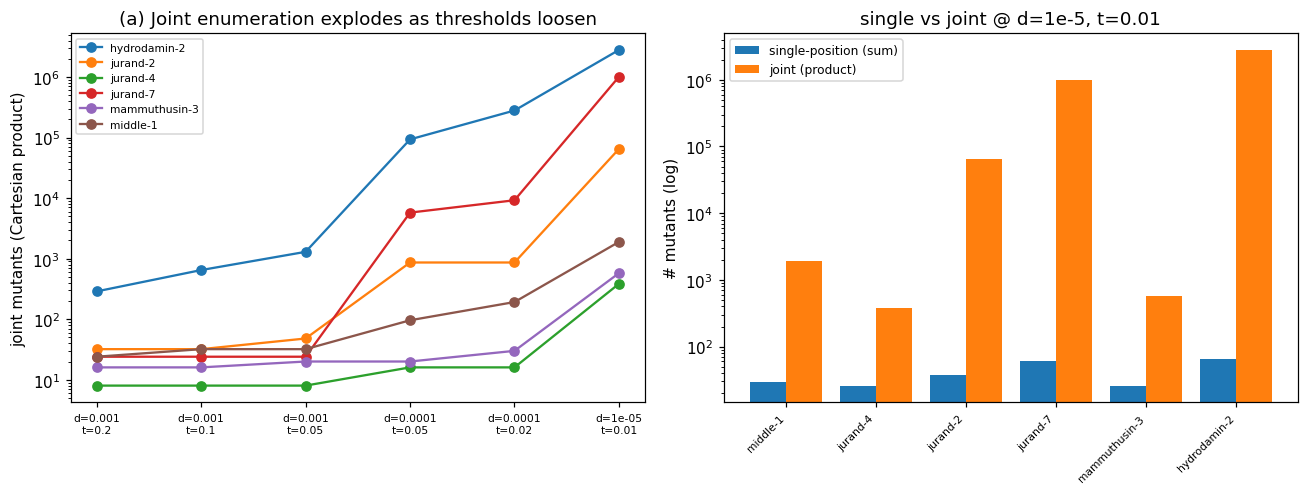

max joint/single ratio across the scan: 43067.1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# left: joint count vs tightening thresholds (log scale), one line per peptide
for name, g in expl_df.groupby("peptide"):
    axes[0].plot(range(len(g)), g["joint_count"].values, marker="o", label=name)
axes[0].set_yscale("log")
axes[0].set_xticks(range(len(explosion_thresholds)))
axes[0].set_xticklabels([f"d={d:g}\nt={t:g}" for d, t in explosion_thresholds], fontsize=7)
axes[0].set_ylabel("joint mutants (Cartesian product)")
axes[0].set_title("(a) Joint enumeration explodes as thresholds loosen")
axes[0].legend(fontsize=7)

# right: single vs joint at the tightest setting
tight = expl_df[(expl_df.d_thresh == 1e-5) & (expl_df.t_thresh == 0.01)]
x = np.arange(len(tight))
axes[1].bar(x - 0.2, tight["single_count"], width=0.4, label="single-position (sum)")
axes[1].bar(x + 0.2, tight["joint_count"], width=0.4, label="joint (product)")
axes[1].set_yscale("log")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tight["peptide"], rotation=45, ha="right", fontsize=7)
axes[1].set_ylabel("# mutants (log)")
axes[1].set_title("single vs joint @ d=1e-5, t=0.01")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("max joint/single ratio across the scan:",
      round((expl_df["joint_count"] / expl_df["single_count"].clip(lower=1)).max(), 1))

**(a) conclusion.** The joint enumeration size is the *product* of per-position branch counts, so it grows multiplicatively while the single-position count grows only additively. As thresholds loosen, the gap widens by orders of magnitude — the Cartesian product is the dominant cost driver and motivates the single-position restriction used by the production script.

## (b) Instability under threshold selection across peptides

There is no universal threshold. We scan the full `direction_significance_threshold` × `token_threshold` grid and look at the **single-position** mutant count per peptide. Then, across many peptides, we measure the **coefficient of variation** (CV = std / mean) of that count per threshold cell: a high CV means one threshold setting behaves wildly differently from peptide to peptide. Finally we measure **set churn** — the Jaccard overlap of the mutant set between adjacent threshold settings on a single peptide.

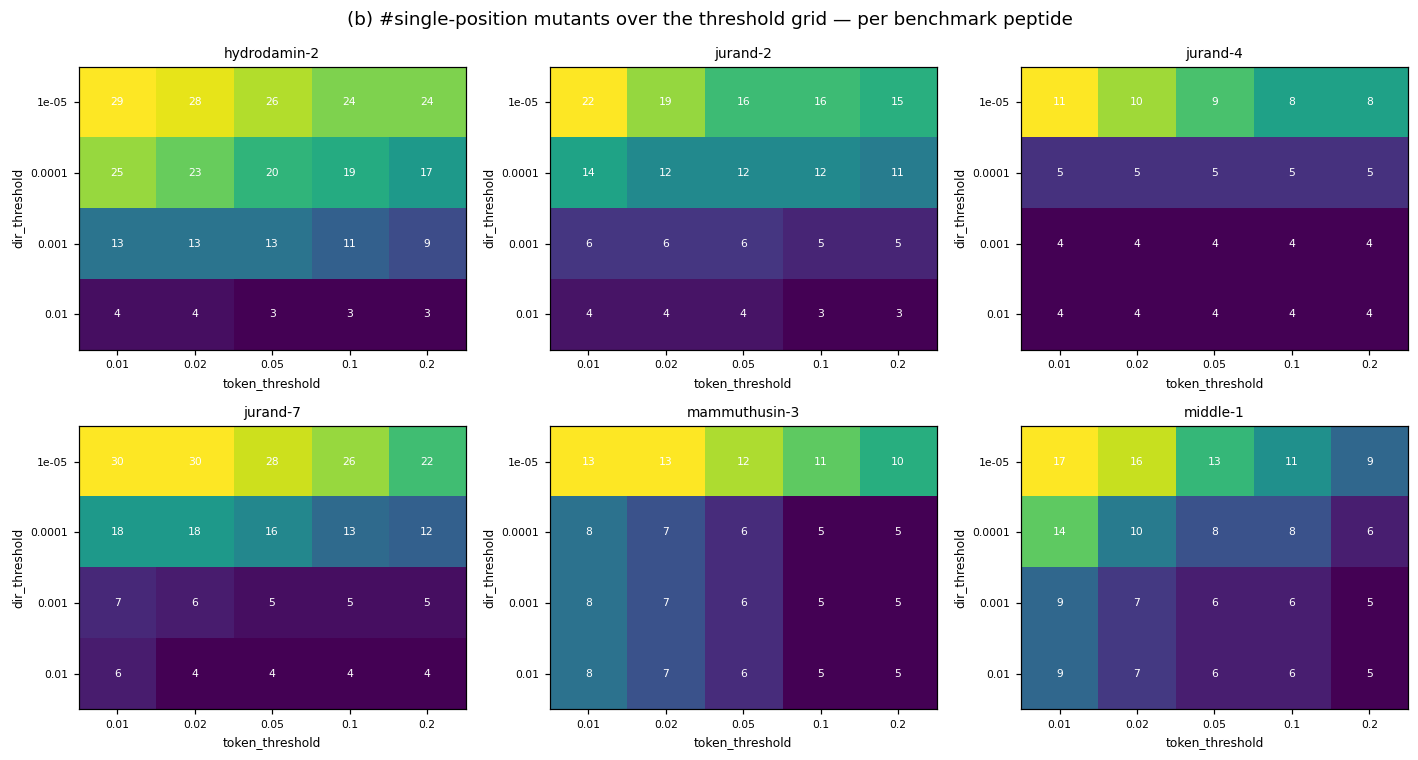

In [5]:
d_grid = [1e-2, 1e-3, 1e-4, 1e-5]
t_grid = [0.20, 0.10, 0.05, 0.02, 0.01]

bench_scan = st.threshold_grid_scan(benchmarks, model, d_grid, t_grid, mode="approx", eps=1e-6, cache=cache)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, g) in zip(axes.ravel(), bench_scan.groupby("peptide")):
    pivot = g.pivot(index="d_thresh", columns="t_thresh", values="n_mutants")
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
    ax.set_title(name, fontsize=9)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{t:g}" for t in pivot.columns], fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{d:g}" for d in pivot.index], fontsize=7)
    ax.set_xlabel("token_threshold", fontsize=8)
    ax.set_ylabel("dir_threshold", fontsize=8)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, int(pivot.values[i, j]), ha="center", va="center", color="w", fontsize=7)
fig.suptitle("(b) #single-position mutants over the threshold grid — per benchmark peptide")
plt.tight_layout(); plt.show()

Most unstable threshold cells (sample_100):


,d_thresh,t_thresh,mean,std,min,max,cv
18,0.010,0.10,9.09,7.031093,2,40,0.773498
17,0.010,0.05,9.82,7.593698,2,40,0.773289
16,0.010,0.02,10.89,8.415828,3,44,0.772803
15,0.010,0.01,11.71,9.043436,3,45,0.772283
19,0.010,0.20,8.54,6.540349,2,38,0.765849
14,0.001,0.20,12.90,9.120407,3,43,0.707008


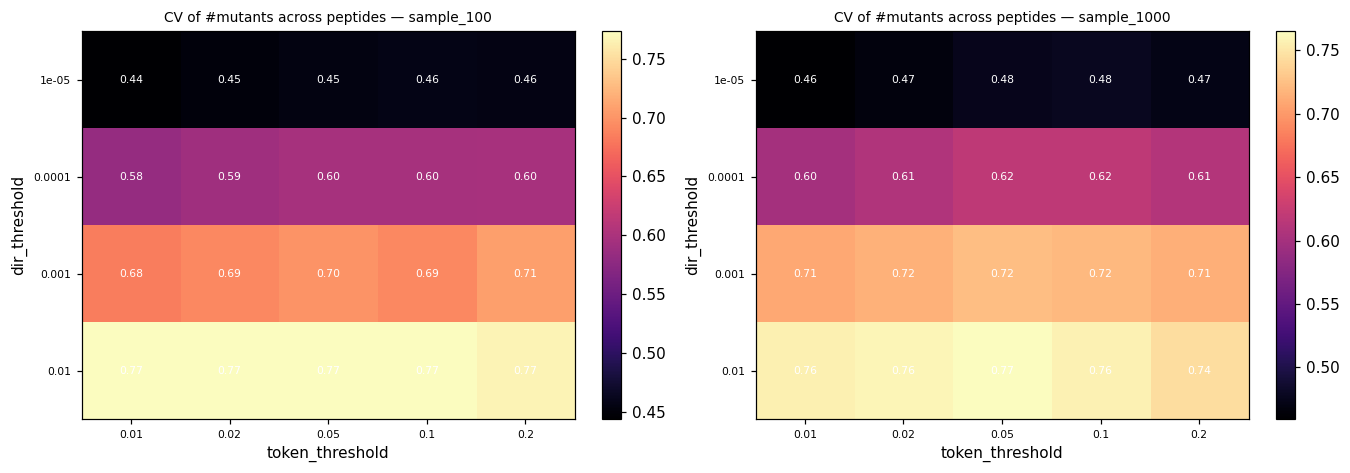

In [6]:
scan_100 = st.threshold_grid_scan(sample_100, model, d_grid, t_grid, mode="approx", eps=1e-6)
frames = {"sample_100": st.cross_peptide_instability(scan_100)}
if RUN_B_1000:
    scan_1000 = st.threshold_grid_scan(sample_1000, model, d_grid, t_grid, mode="approx", eps=1e-6)
    frames["sample_1000"] = st.cross_peptide_instability(scan_1000)

print("Most unstable threshold cells (sample_100):")
display(frames["sample_100"].sort_values("cv", ascending=False).head(6))

fig, axes = plt.subplots(1, len(frames), figsize=(6.2 * len(frames), 4.4), squeeze=False)
for ax, (label, cv) in zip(axes.ravel(), frames.items()):
    pivot = cv.pivot(index="d_thresh", columns="t_thresh", values="cv")
    im = ax.imshow(pivot.values, aspect="auto", cmap="magma")
    ax.set_title(f"CV of #mutants across peptides — {label}", fontsize=9)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{t:g}" for t in pivot.columns], fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{d:g}" for d in pivot.index], fontsize=7)
    ax.set_xlabel("token_threshold"); ax.set_ylabel("dir_threshold")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f"{v:.2f}" if np.isfinite(v) else "–", ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

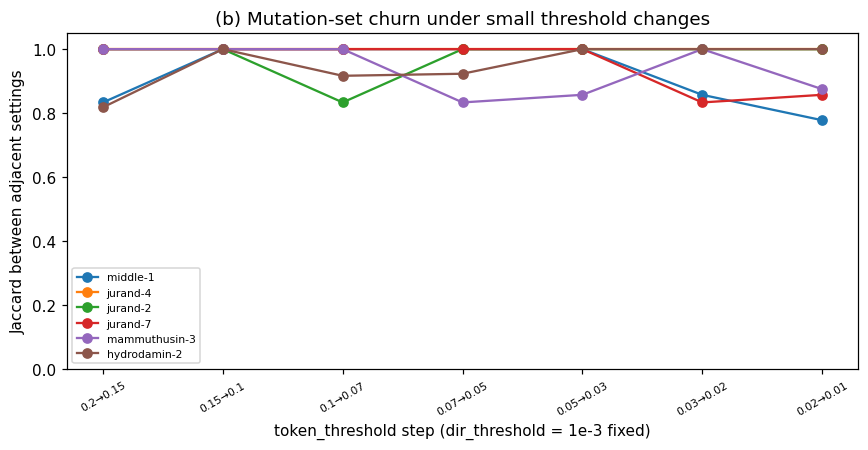

In [7]:
# Set churn: Jaccard overlap of the mutant set between adjacent token thresholds
path = [(1e-3, t) for t in [0.20, 0.15, 0.10, 0.07, 0.05, 0.03, 0.02, 0.01]]
plt.figure(figsize=(8, 4.2))
for name, seq in benchmarks.items():
    U, S = st.compute_svd(model, seq, mode="approx", eps=1e-6, cache=cache)
    curve = st.set_sensitivity_curve(seq, S, U, path)
    plt.plot(range(len(curve)), curve, marker="o", label=name)
plt.xticks(range(len(path) - 1),
           [f"{path[i][1]:g}→{path[i+1][1]:g}" for i in range(len(path) - 1)], fontsize=7, rotation=30)
plt.ylabel("Jaccard between adjacent settings"); plt.ylim(0, 1.05)
plt.xlabel("token_threshold step (dir_threshold = 1e-3 fixed)")
plt.title("(b) Mutation-set churn under small threshold changes")
plt.legend(fontsize=7); plt.tight_layout(); plt.show()

**(b) conclusion.** The per-peptide heatmaps have no common structure — the same threshold cell yields a handful of mutants for one peptide and many for another. Across 100/1000 peptides the coefficient of variation is large (often > 0.5), so **no single threshold generalizes**. The churn curves show Jaccard well below 1 for small threshold steps, i.e. the enumerated set is unstable to threshold choice. Any fixed default silently changes Mutang's behaviour from peptide to peptide.

## (c) Sensitivity to Jacobian approximation quality

Mutang can use the **exact** Jacobian (`strict`, autograd) or a **finite-difference approximation** (`approx`) with step `jacobian_eps`. We sweep `eps` and, against the exact Jacobian, measure:

- **`jac_rel_error`** — relative Frobenius error of the Jacobian itself.
- **`sv_rel_error`** — relative error of the top-10 singular values.
- **`subspace_overlap`** — mean cosine of principal angles between the top-10 left-singular subspaces (1 = identical).
- **`mut_jaccard`** — overlap of the resulting single-position mutation sets.

Finite differences trade two error sources: **truncation** (large `eps`) vs **floating-point cancellation** (tiny `eps`), giving a characteristic U-shaped error curve with a sweet spot in between.

In [8]:
eps_grid = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
D_C, T_C = 1e-3, 0.05  # fixed Mutang thresholds for the mutation-set comparison

eps_bench = st.eps_sensitivity_scan(benchmarks, model, eps_grid, D_C, T_C, k=10)

c_peptides = sample_1000 if RUN_C_1000 else sample_100[:SAMPLE_C]
print(f"(c) eps sweep over {len(c_peptides)} sampled peptides × {len(eps_grid)} eps — each needs one exact Jacobian...")
eps_sample = st.eps_sensitivity_scan(c_peptides, model, eps_grid, D_C, T_C, k=10)
display(eps_bench.head())

(c) eps sweep over 100 sampled peptides × 8 eps — each needs one exact Jacobian...


,peptide,eps,jac_rel_error,subspace_overlap,sv_rel_error,mut_jaccard
0,middle-1,0.10000,557.648682,0.848954,556.725098,0.625000
1,middle-1,0.01000,0.175326,0.710177,0.064153,1.000000
2,middle-1,0.00100,0.354797,0.687985,0.163755,0.714286
3,middle-1,0.00010,2.337113,0.730469,1.790955,0.571429
4,middle-1,0.00001,8.697900,0.727109,8.172386,0.714286


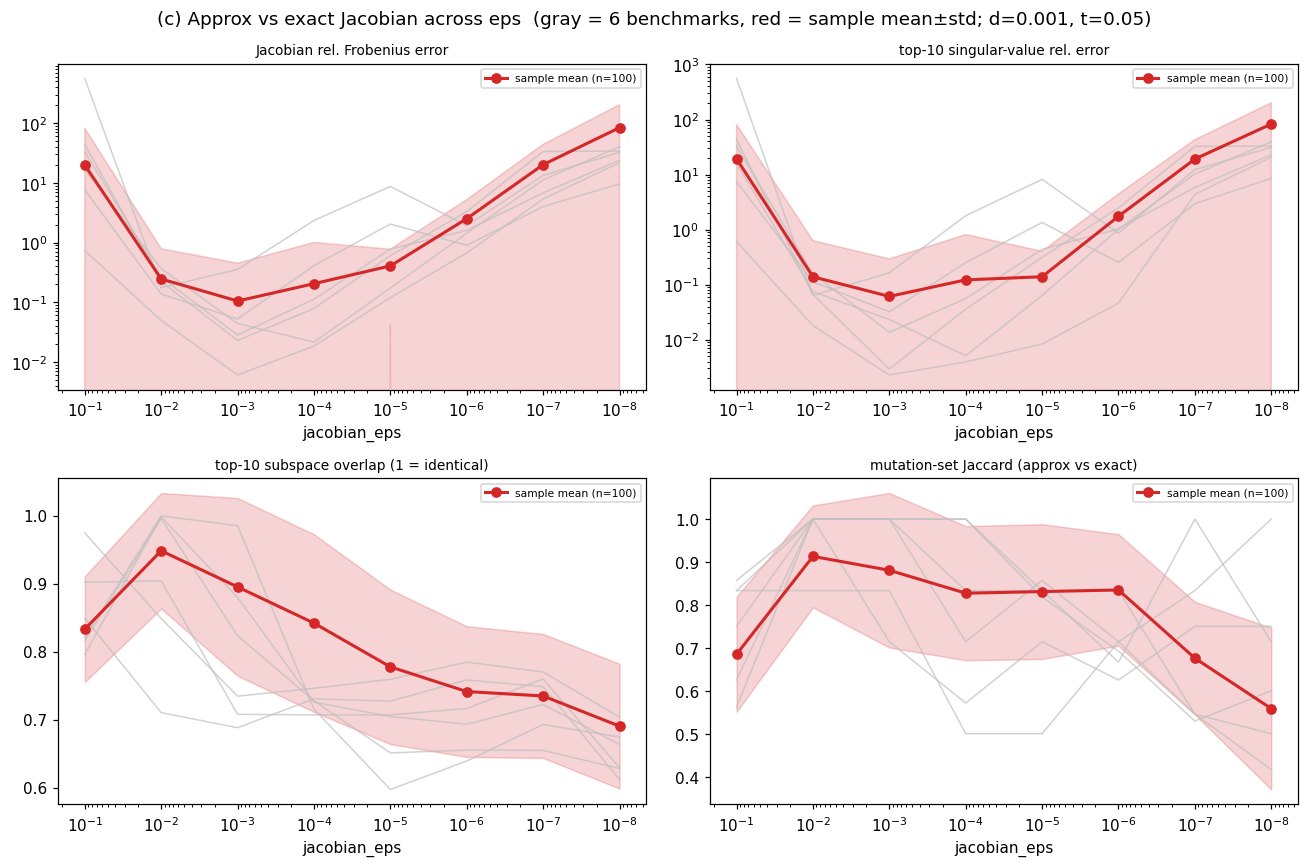

eps maximizing mean mutation-set Jaccard vs exact: 0.01
eps with worst mean Jacobian error: 1e-08


In [9]:
metrics = [
    ("jac_rel_error", "Jacobian rel. Frobenius error", True),
    ("sv_rel_error", "top-10 singular-value rel. error", True),
    ("subspace_overlap", "top-10 subspace overlap (1 = identical)", False),
    ("mut_jaccard", "mutation-set Jaccard (approx vs exact)", False),
]
metric_cols = [m[0] for m in metrics]
agg = eps_sample.groupby("eps")[metric_cols].agg(["mean", "std"])
n_samp = eps_sample.peptide.nunique()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, title, logy) in zip(axes.ravel(), metrics):
    for _, g in eps_bench.groupby("peptide"):
        ax.plot(g["eps"], g[col], color="0.75", lw=1, alpha=0.7)
    m, s = agg[col]["mean"], agg[col]["std"]
    ax.plot(m.index, m.values, color="C3", marker="o", lw=2, label=f"sample mean (n={n_samp})")
    ax.fill_between(m.index, (m - s).values, (m + s).values, color="C3", alpha=0.2)
    ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.invert_xaxis()  # loose (large eps) -> tight (small eps), left to right
    ax.set_xlabel("jacobian_eps"); ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle(f"(c) Approx vs exact Jacobian across eps  (gray = 6 benchmarks, red = sample mean±std; d={D_C}, t={T_C})")
plt.tight_layout(); plt.show()

best = eps_sample.groupby("eps")["mut_jaccard"].mean().idxmax()
worst = eps_sample.groupby("eps")["jac_rel_error"].mean().idxmax()
print(f"eps maximizing mean mutation-set Jaccard vs exact: {best:g}")
print(f"eps with worst mean Jacobian error: {worst:g}")

**(c) conclusion.** The Jacobian error is **U-shaped** in `eps`: large `eps` incurs truncation error, very small `eps` incurs floating-point cancellation. Crucially, the error propagates downstream — the singular subspace rotates and the resulting **mutation set diverges from the exact one** (Jaccard < 1) when `eps` is off the sweet spot. Mutang's output therefore depends materially on a numerical hyperparameter that has nothing to do with biology; the default `jacobian_eps` should be chosen near the empirical sweet spot reported above.

## Summary — answers to RQ3

**(a) Combinatorial explosion.** Joint enumeration is the Cartesian product of per-position candidate residues, so its size is the *product* of branch counts and grows multiplicatively as thresholds loosen, while single-position enumeration grows only additively. This is why the production pipeline restricts to single-position mutations.

**(b) Threshold instability across peptides.** The `direction` × `token` threshold grid produces per-peptide mutant counts with no shared structure; across 100–1000 peptides the coefficient of variation per threshold cell is large, and the mutant set churns (low Jaccard) under small threshold changes. There is no universal threshold — any fixed default silently changes behaviour per peptide.

**(c) Jacobian-approximation sensitivity.** The finite-difference Jacobian error is U-shaped in `eps` (truncation vs cancellation). Off the sweet spot, the SVD subspace rotates and the enumerated mutation set diverges from the exact-Jacobian result, so Mutang's output is sensitive to a purely numerical hyperparameter.

**Peptide-count justification.** 6 benchmark peptides (the actual optimization targets, lengths 10–19) give per-peptide detail and bound the cost of the exact-Jacobian sweep; 100 sampled peptides give meaningful cross-peptide statistics; 1000 confirms the instability trend is not a small-sample artifact.